## CMPINF 2100 Week 07 - OPTIONAL Reading

### Beyond the scatter plot

Scatter plots are essential graphic tools for visualizing the relationship between two continuous variables. However, there are several more advanced plots that can help overcome certain limitations of the scatter plot when we wish to focus on the **densitny** or where observations are **concentrated**. These more advanced plot types are addressed in detail in CMPINF 2130. Thus, you are not required to go through these plots right now in CMPINF 2100. This is an optional reading provided if you would like to jump start further visualizations to help explore relationships between continuous variables. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read data
We will continue to use the penguins data set

In [4]:
penguins = sns.load_dataset('penguins')

In [5]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## 2D Distributions
The scatter plot visualizes relationships. For example the scatter plot below shows the relationship between `bill_depth_mm` and `flipper_length_mm`.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


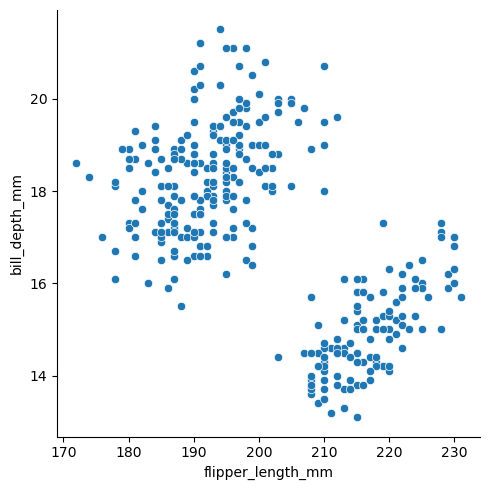

In [6]:
sns.relplot(data = penguins, x='flipper_length_mm', y='bill_depth_mm')
plt.show()

However, the scatter plot does not tell us if there are **multiple** observations at the same location. Multiple markers could be on top of each other and we would **not** know that from the scatter plot! Our current application does not have a lot of data, so we do not really need to be concerned that such is taking place. However, let's raise the marker size so that multiple markers overlap each other. It is trickier to see things in the figure below because markers interfere with each other.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


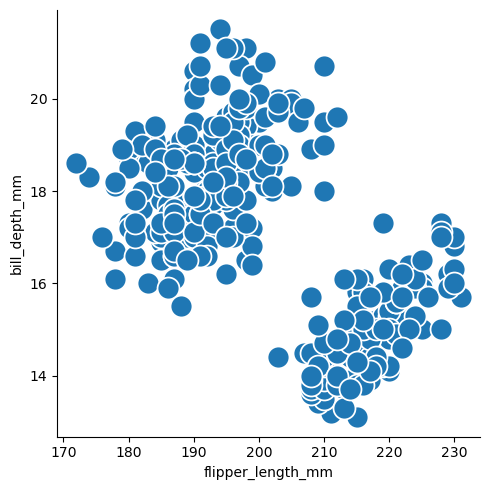

In [7]:
sns.relplot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', s=250)
plt.show()

One way to overcome overlap is to change the marker **transparency**. Reducing the transparency allows visualizing **density** or **concentration** of observation. Transparency is controlled by the `alpha` argument. The figure below required 3 markers on top of each other in order to show a fully opaque point

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


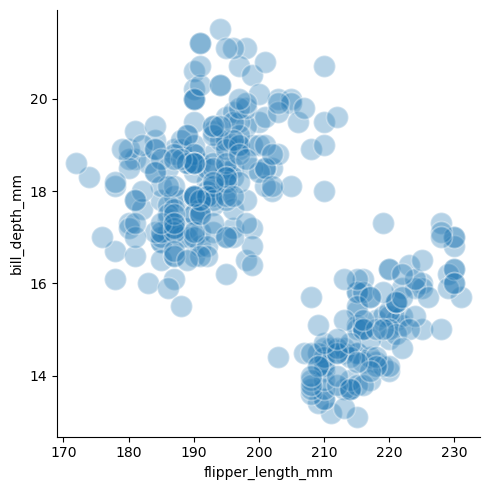

In [8]:
sns.relplot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', 
            s=250,
           alpha=0.33)
plt.show()

 It is difficult to know the best transparency value to use though. A very low value makes it difficult to see anything!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


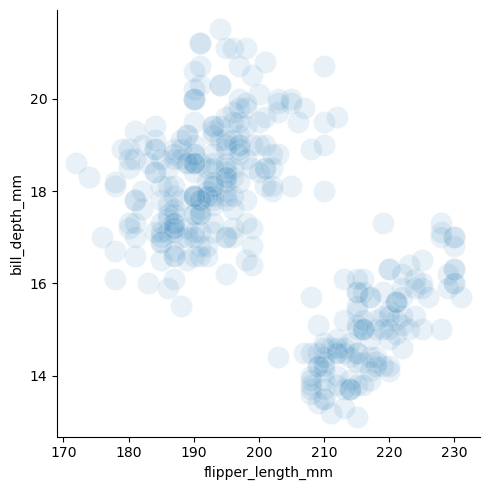

In [9]:
sns.relplot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', 
            s=250,
           alpha=0.1)
plt.show()

Instead, 2D histograms divide the space into small bins and count the number of observations in the bin! This is exactly what a "regular" histogram does, except now we have bins in **two** directions! The 2D histogram is created with the FIGURE LEVEL function `sns.displot()` because the goal is to study a Distribution. We must assign an `x` axis variable **and** a `y` axis variable to create the 2D histogram. Marginal histograms involving one and only variable only require `x` to be assigned.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


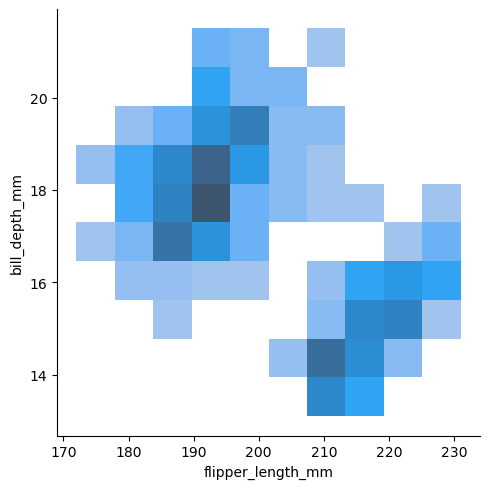

In [10]:
sns.displot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='hist')
plt.show()

The color bar can be included so we know roughly how many observations are in each bin. The color bar makes it clear that the DARKER the bin color the more observations are CONCENTRATED within that region. Higher concentration represetns the DENSITY is higher!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


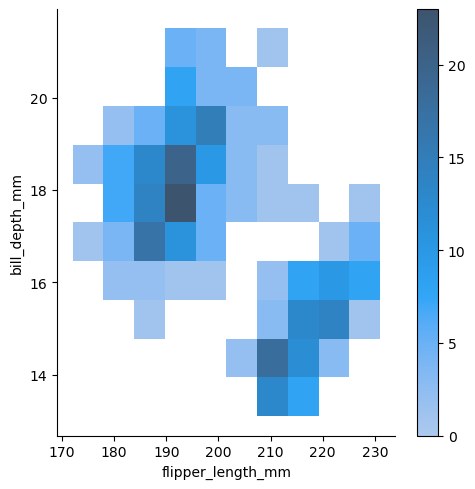

In [11]:
sns.displot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='hist',
           cbar=True)
plt.show()

We can facet 2D histogram by a grouping variable. This lets ud explore if the CONCENTRATED regions DEPEND on a categorical variable!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


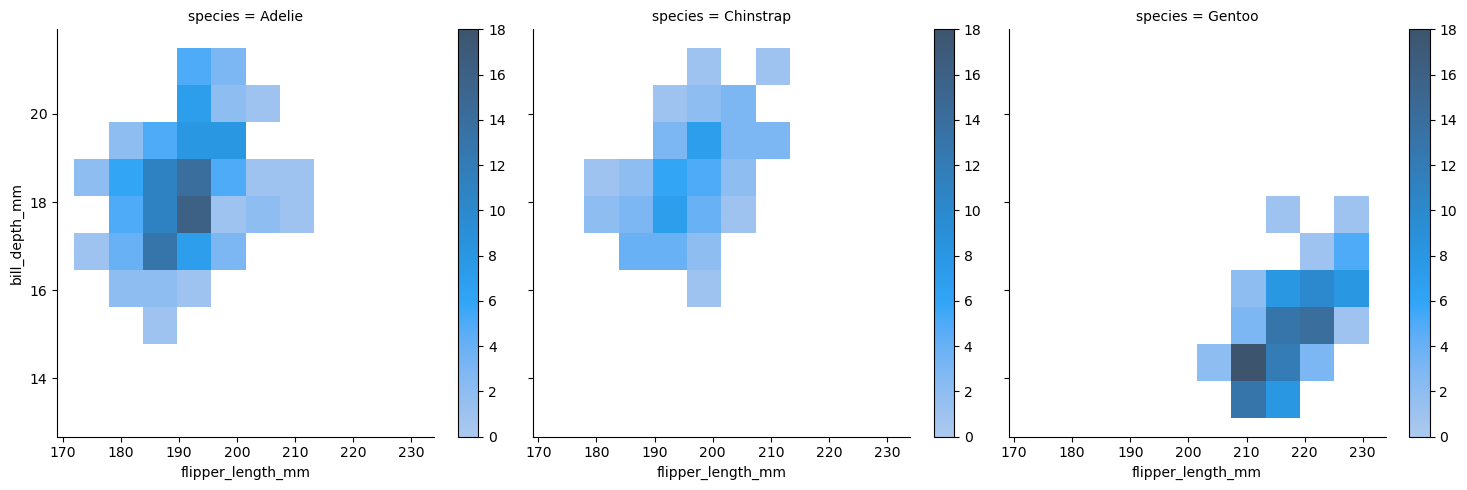

In [12]:
sns.displot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', col='species',
            kind='hist',
           cbar=True)
plt.show()

We can also color bya grouping variable, however it is not recommended to have the overlap filled colored regions. CMPINF 2130 discusses why that is the case.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


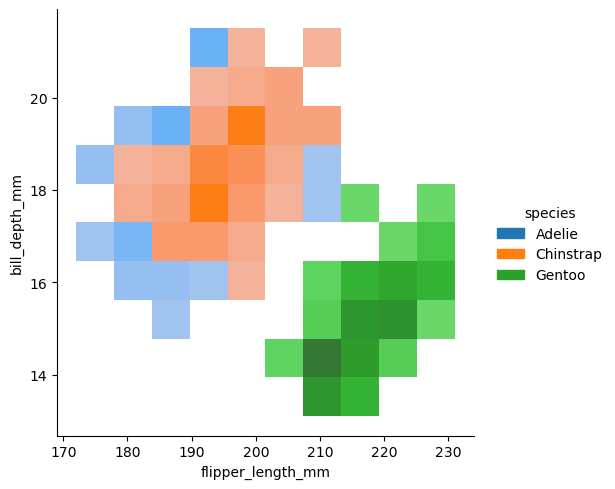

In [14]:
sns.displot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', hue='species',
            kind='hist')
plt.show()

An alternative to the 2D histogram is the **2D density plot**. The 2D density is like the KDE plot for a single variable. It smooths the 2D distribution and uses contour lines to show regions of high density (concentration) and low density (few observations).

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


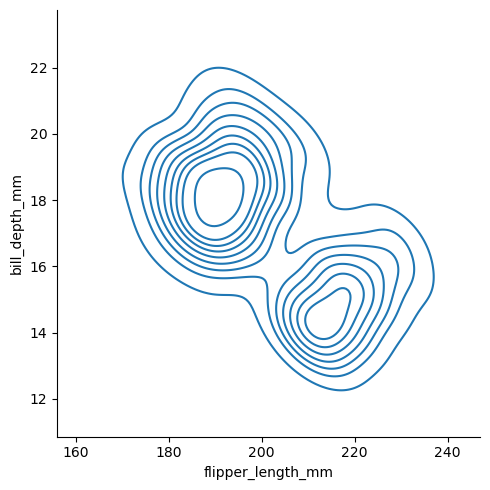

In [16]:
sns.displot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='kde')
plt.show()

2D density plots can be faceted as well.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


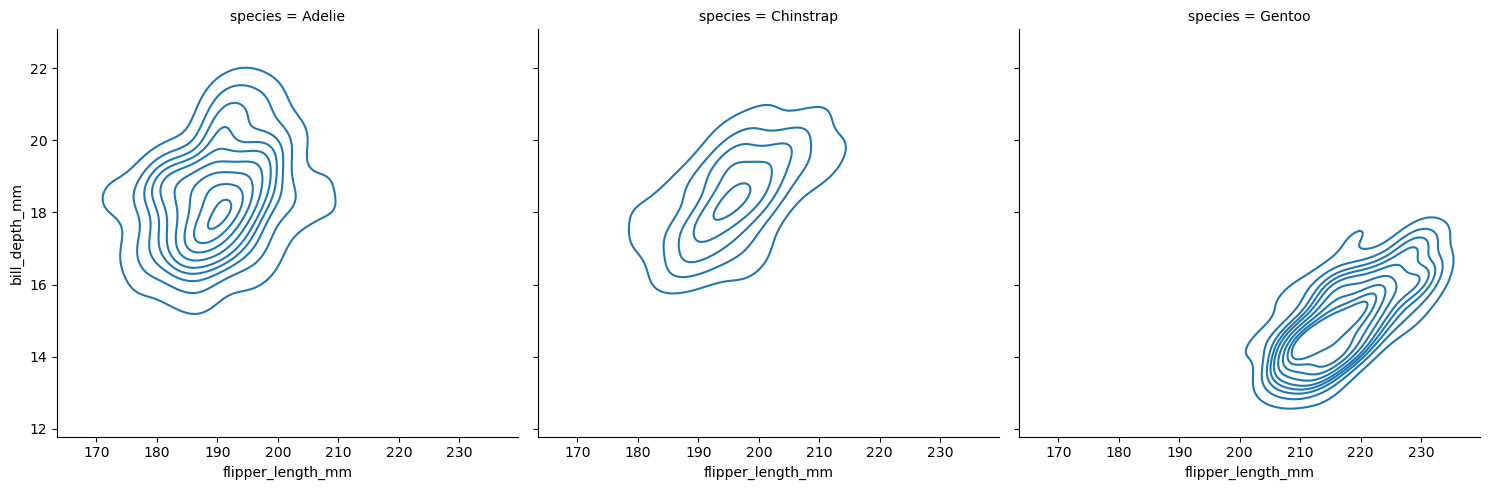

In [17]:
sns.displot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='kde', col='species')
plt.show()

But, 2D density are easier to interpret when we color by a grouping variable compared to 2D histograms. We can now see OVERLAPPING regions because the colors only apply to the contour curves! The 2D Density plot makes it easy to see that the Adelie and Chinstrap `species` are in roughly the same region!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


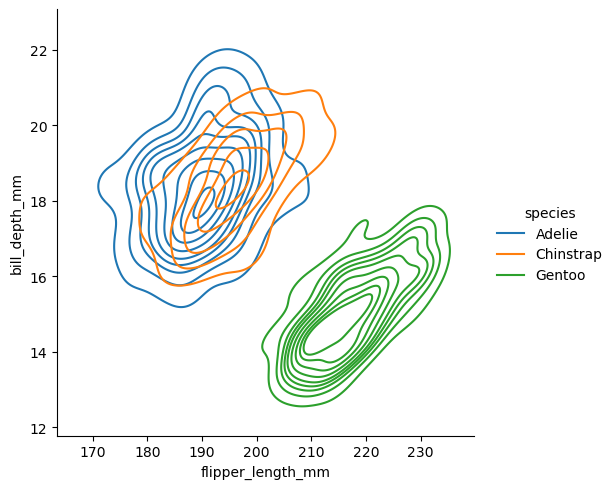

In [18]:
sns.displot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='kde', hue='species')
plt.show()

## Combining marginal and joint distributions
Histograms or density plots let us examine the distribution a single variable. This kind of plot is  known as **marginal distribution** if we completely ignore all other variables. For example, the marginal distribution of `flipper_length_mm` is shown below:

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


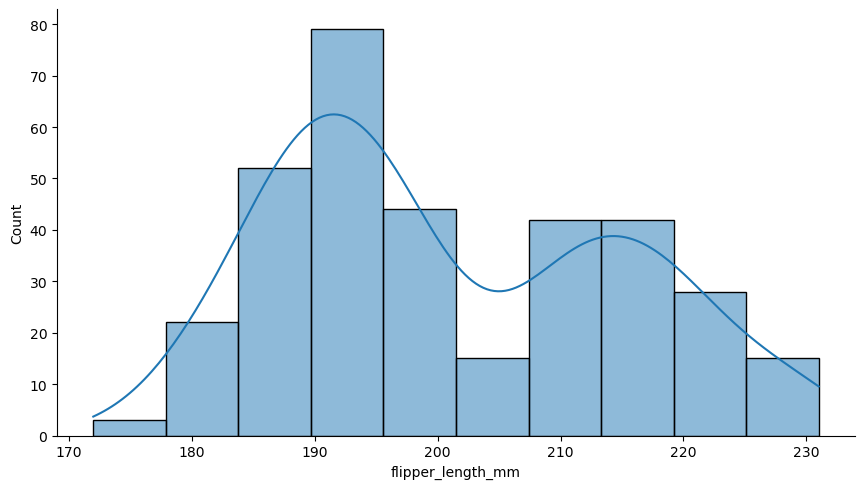

In [19]:
sns.displot( data = penguins, x='flipper_length_mm', kind='hist', kde=True, aspect=1.75)
plt.show()

We can also look at the marginal distribution of `bill_depth_mm`

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


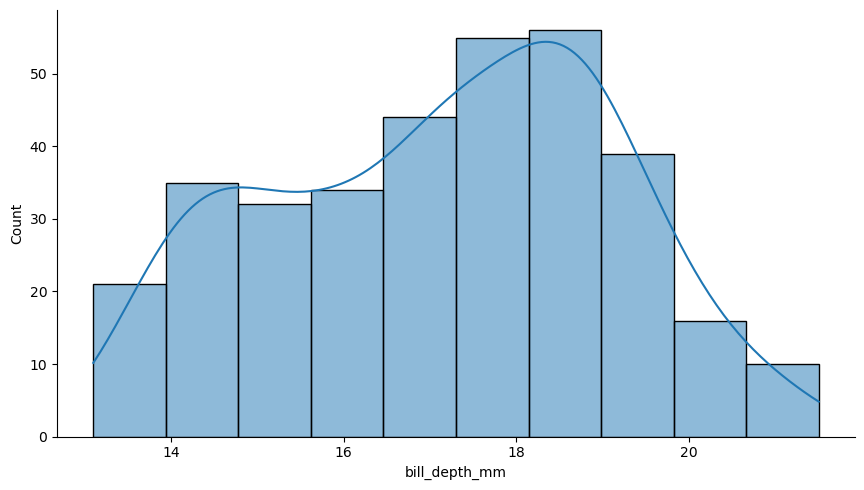

In [20]:
sns.displot( data = penguins, x='bill_depth_mm', kind='hist', kde=True, aspect=1.75)
plt.show()

Scatter plots, 2D histograms, and 2D density plots examine the relationship between variables. We are studying how the variables change at the same time or we can say we are sudying the **JOINT** behavior of the variables. We can combine **marginal** and **joint** behavior within a SINGLE graphic known as the **joint plot** within Seaborn, The `sns.jointplot()` function shows the relationship plot in the main axes and the **marginal** plots outside the axis boundary. A scatter plot is used by default as shown below.

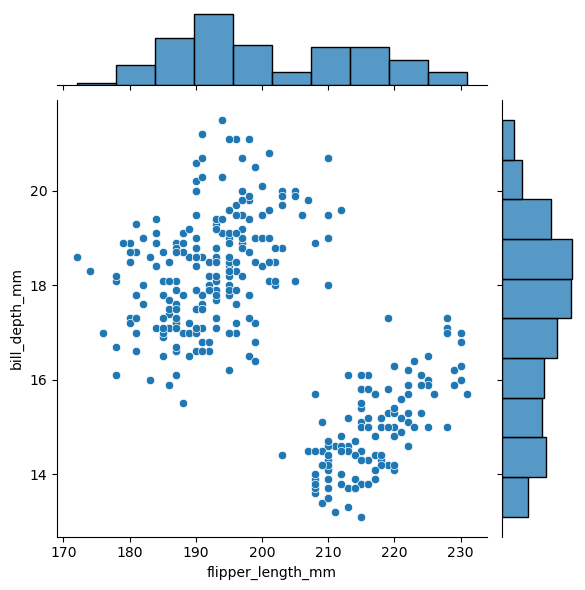

In [21]:
sns.jointplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm')
plt.show()

We can use a 2D histogram instead of the scatter plot to show the JOINT behavior.

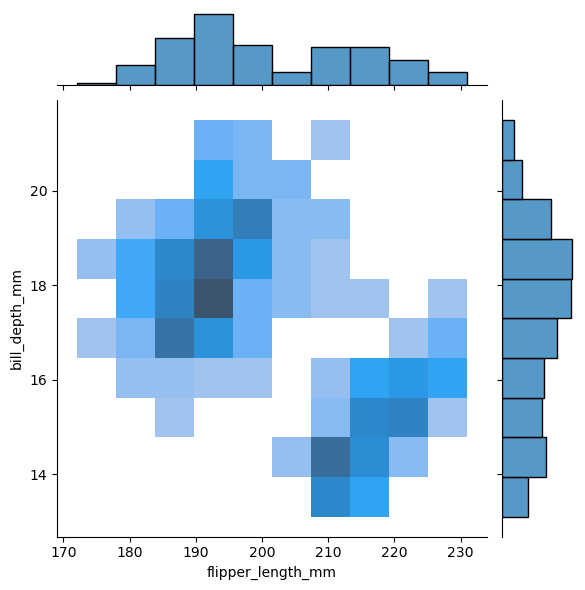

In [22]:
sns.jointplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='hist')
plt.show()

The `sns.jointplot()` function allows the 2D histogram to be represented by HEXAGONS instead of rectangles.

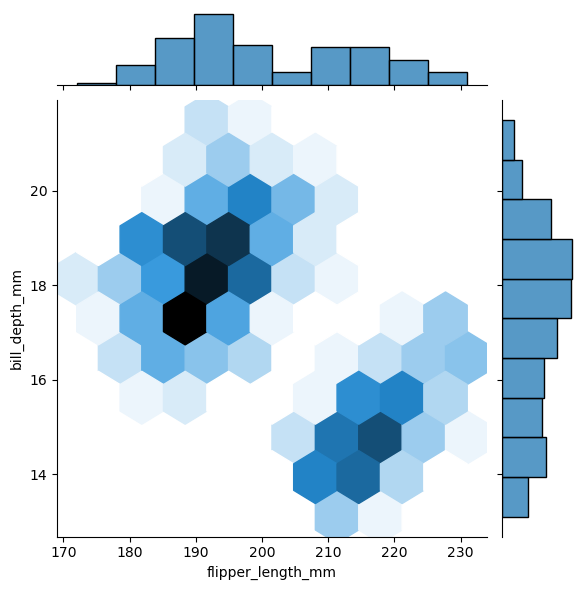

In [23]:
sns.jointplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='hex')
plt.show()

We can change the number of bins in the marginal histograms using the `marginal_kws` argument.

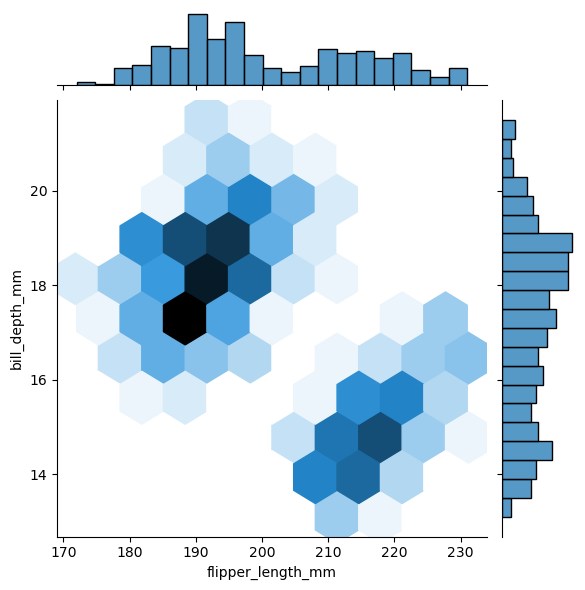

In [24]:
sns.jointplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='hex',
              marginal_kws={'bins':21})
plt.show()

We can also switch to using KDE plots instead of the histograms.

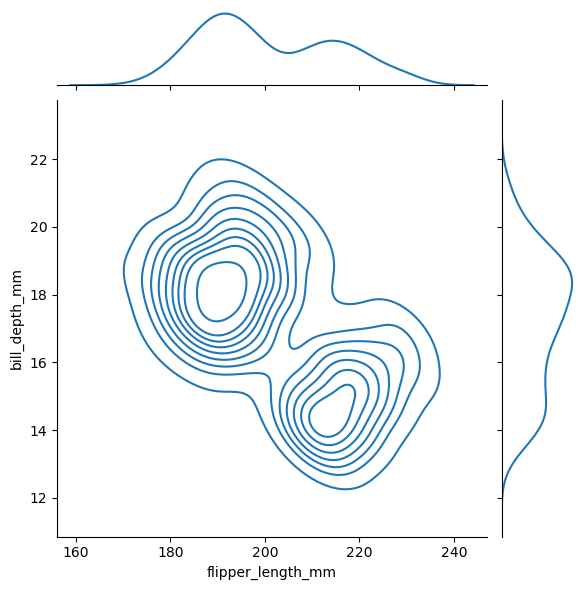

In [25]:
sns.jointplot(data = penguins, x='flipper_length_mm', y='bill_depth_mm', kind='kde')
plt.show()

KDE **joint plots** are easier to interpret wehn we color by a grouping variable compared to the histograms.

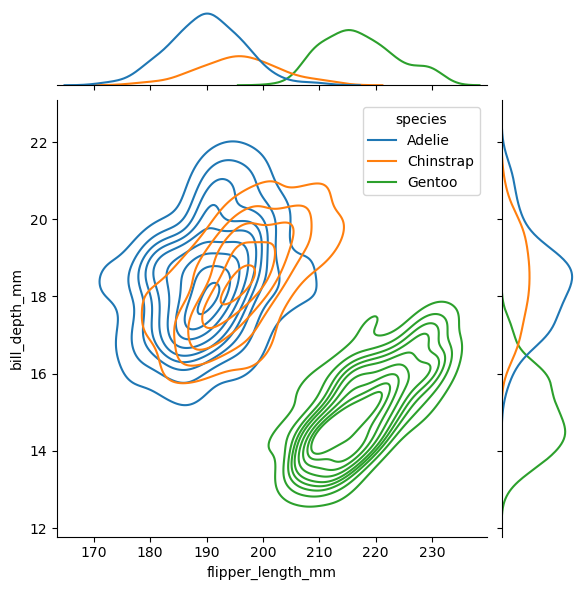

In [26]:
sns.jointplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', hue='species',
              kind='kde')
plt.show()

However the JOINT PLOT above is **WRONG**! We must always remember to set `common_norm` to false!

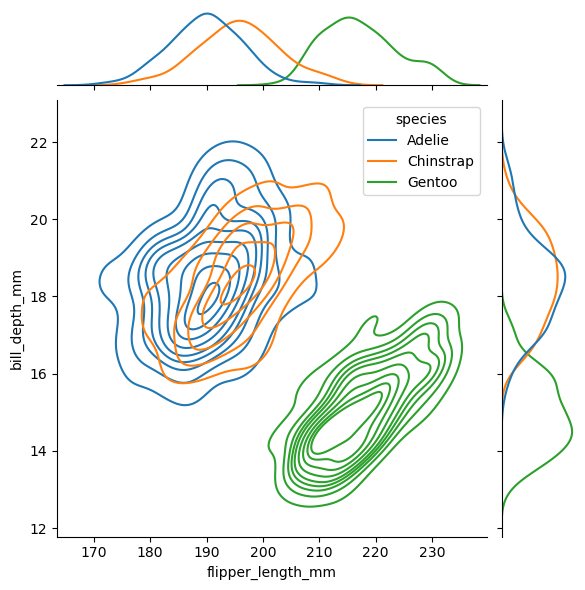

In [27]:
sns.jointplot( data = penguins, x='flipper_length_mm', y='bill_depth_mm', hue='species',
              kind='kde',
              marginal_kws={'common_norm': False})
plt.show()

## Why does this matter?
The scatter plot is sufficient for the penguins data example. However, let's look at another example which will help showcase the usefulness of the 2D histogram and 2D density plot. The cell below reads the diamonds dataset from Seaborn.

In [28]:
diamonds = sns.load_dataset("diamonds")

In [29]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


There are over 50000 rows! The variables of `diamonds` correspond to features/attributes of diamonds. The `price` variable is the sale price of the diamond in US Dollars. Let's examine the relationship between the `carat` and the `price`

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


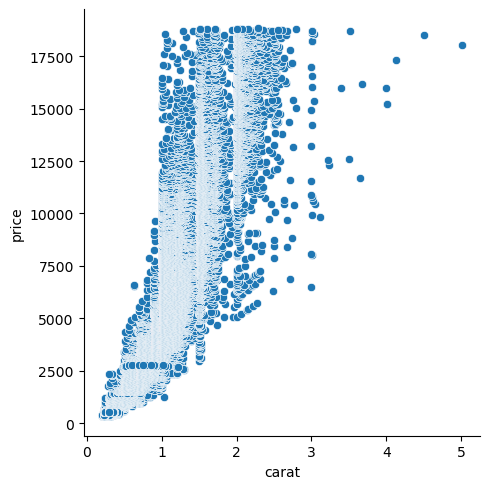

In [30]:
sns.relplot(data = diamonds, x='carat', y='price')
plt.show()

the above scatter plot shows that increasing `carat` generally increases the `price`. However, the middle of the plot looks really strange. this is due to the large number of overlapping markers. Instead of showing each individual observations as a marker, let's use a 2D histogram to focus on intervals with many observations.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


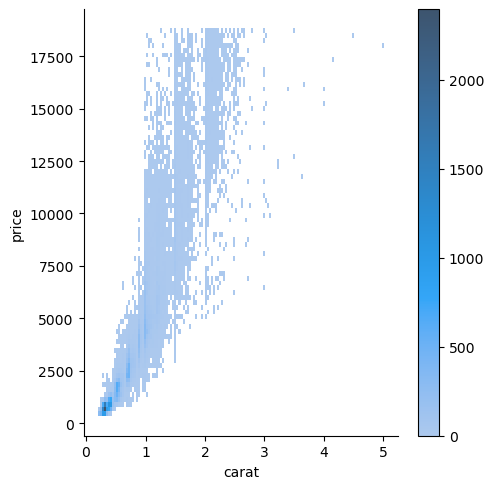

In [31]:
sns.displot(data = diamonds, x='carat', y='price', cbar=True)
plt.show()

The dark blue region in the lower corner of the above plot consists of the most observations! We can change the number of bins similar to how we can change the bins in the "regular" 1D histogram.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


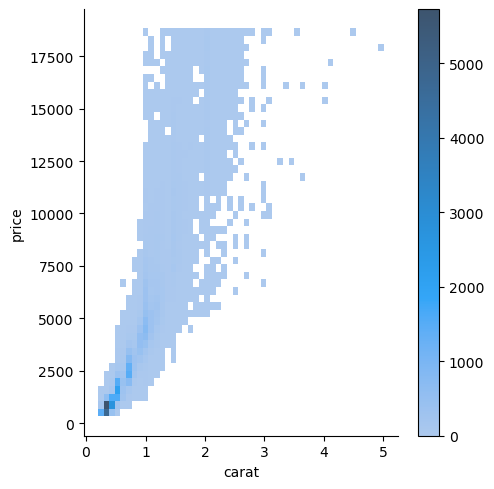

In [32]:
sns.displot(data = diamonds, x='carat', y='price', cbar=True,
            bins=51)
plt.show()

Alternatively, we can visualize the relationship using a 2D density plot. The 2D density plot helps us focus on the regions where the data are most concentrated. The extreme points appear to be "trimmed" but that simply represents how few observations are present in those extreme outer locations. That is why there are no circles near the top right corner with `carat` near 5. Please note the figure below (may take a LONG time to produce)!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


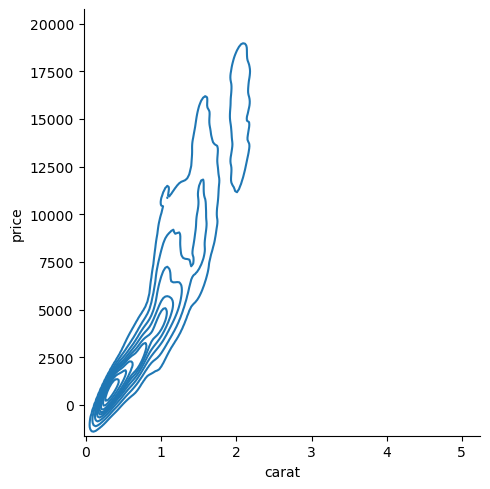

In [33]:
sns.displot(data = diamonds, x='carat', y='price', kind='kde')
plt.show()

Including the MARGINAL KDE plots with the JOINT or 2D KDE provides further context to interpreting the joing behavior! It shows us that the highest DENSITY region in the lower left hand cornder is associated with the highest density intervals for the two varialbes by themselves!

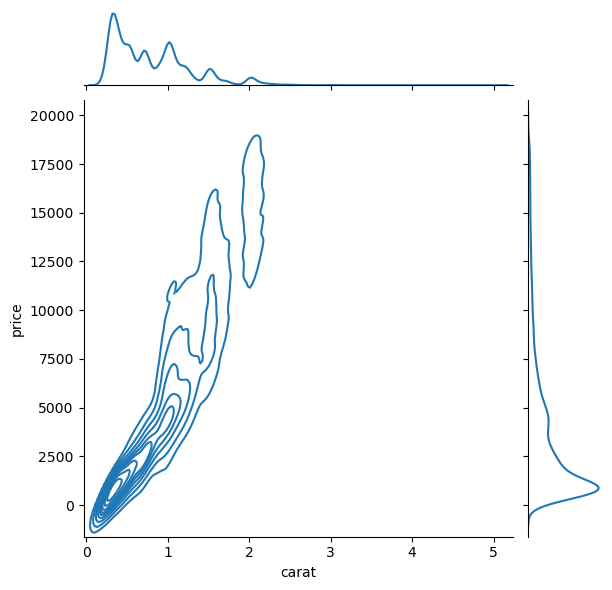

In [35]:
sns.jointplot( data = diamonds, x='carat', y='price', kind='kde')
plt.show()

## Summary
This was just a quick introduction to these advanced 2D graphics. We spend more time with them in CMPINF 2130. The art of Data Visualization